In [50]:
from Models.Materials import Concrete, Rebar
from Models.Results import PunchingShearInput
from Core.Geometry import ColumnLocation, calculate_punching_properties
from Codes.CSA_A23_3_19 import (
    calc_vc_unreinforced,
    calc_gamma_v,
    calc_max_shear_stress,
    check_maximum_ssr_stress,
    design_ssr_rails
)

In [51]:
# 1. Define Materials
concrete = Concrete(
    name="35MPa", # Any string
    fc=35, # MPa
    unit_weight=24.0 # kN/m3
)

rebar = Rebar(
    name="400W", # any string
    fy=400 # MPa
)

# 2. Define Input Data
inputs = PunchingShearInput(
    slab_thickness=250.0, # mm
    c_top=30.0, # Slab top cover, mm
    c_bot=30.0, # Slab bottom cover m
    c1=300.0, # Column width (x-axis), mm
    c2=600.0, # Column depth (y-axis), mm
    x_c=0.0, # Column location (x-axis)
    y_c=0.0, # Column location (y-axis)
    Vf=900.0, # Shear force, kN
    Mf_x=120.0, # Unbalanced moment about x-axis, kNm
    Mf_y=--150.0, # Unbalanced moment about y-axis, kNm
    concrete=concrete, rebar=rebar, location=ColumnLocation.INTERIOR
)

# An edge column boundary to test the edge truncation
# App will consider edges closer than 5d as a free edges and treat to column os am interior, edge or corner column as required
slab_bounds = [
    -5000.0, # Slab edge location to left of column, mm
    -5000.0, # Slab edge location to bottom of column, mm
    1000.0, # Slab edge location to right of column, mm
    5000.0 # Slab edge location to top of column, mm
]

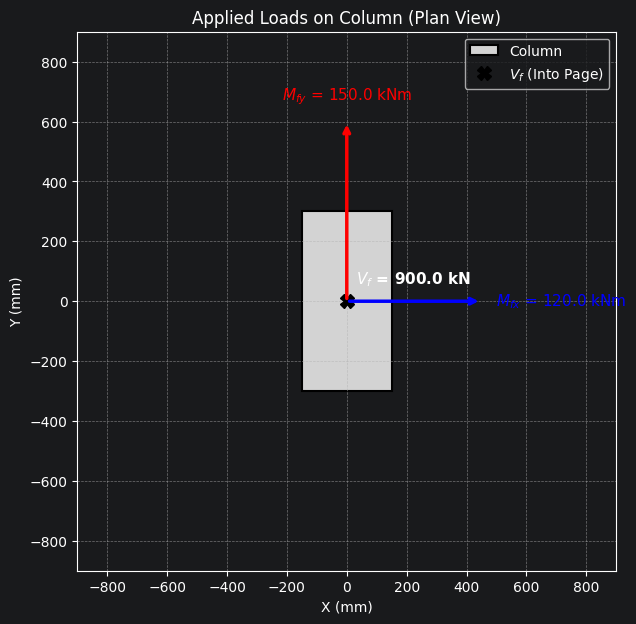

In [52]:
# 6. Plot Applied Loads
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(7, 7))

x_c, y_c = inputs.x_c, inputs.y_c
c1, c2 = inputs.c1, inputs.c2

# Plot Column
column_patch = patches.Rectangle(
    (x_c - c1 / 2, y_c - c2 / 2), c1, c2,
    linewidth=1.5, edgecolor='black', facecolor='lightgray', label='Column'
)
ax.add_patch(column_patch)

# Plot Shear Force (Vf) at Centroid
ax.plot(x_c, y_c, 'kX', markersize=10, label='$V_f$ (Into Page)')
ax.text(x_c + c1 * 0.1, y_c + c2 * 0.1, f"$V_f$ = {inputs.Vf:.1f} kN", fontsize=11, fontweight='bold')

# Plot Unbalanced Moment (Mf_x) Vector (Right-Hand Rule)
if inputs.Mf_x != 0:
    dir_x = 1 if inputs.Mf_x > 0 else -1
    ax.annotate('', xy=(x_c + dir_x * (c1 / 2 + 300), y_c), xytext=(x_c, y_c),
                arrowprops=dict(arrowstyle="->", color="blue", lw=2.5))
    ax.text(x_c + dir_x * (c1 / 2 + 350), y_c, f"$M_{{fx}}$ = {inputs.Mf_x:.1f} kNm",
            color='blue', fontsize=11, va='center', ha='left' if dir_x > 0 else 'right')

# Plot Unbalanced Moment (Mf_y) Vector (Right-Hand Rule)
if inputs.Mf_y != 0:
    dir_y = 1 if inputs.Mf_y > 0 else -1
    ax.annotate('', xy=(x_c, y_c + dir_y * (c2 / 2 + 300)), xytext=(x_c, y_c),
                arrowprops=dict(arrowstyle="->", color="red", lw=2.5))
    ax.text(x_c, y_c + dir_y * (c2 / 2 + 350), f"$M_{{fy}}$ = {inputs.Mf_y:.1f} kNm",
            color='red', fontsize=11, ha='center', va='bottom' if dir_y > 0 else 'top')

# Formatting
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.6)

margin = max(c1, c2) * 1.5
ax.set_xlim(x_c - margin, x_c + margin)
ax.set_ylim(y_c - margin, y_c + margin)

ax.set_title("Applied Loads on Column (Plan View)")
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")

plt.legend()
plt.show()

--- Critical Shear Perimeter ---


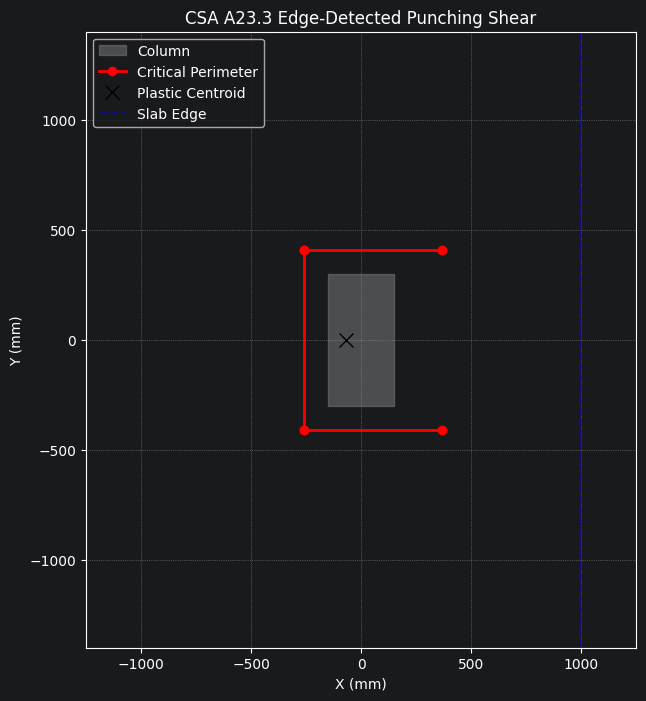

b0: 2080.0 mm
Ac: 457600.0 mm²
Centroid (x, y): (-69.2, 0.0) mm
Eccentricity (e_x, e_y): (-69.2, 0.0) mm
Jx: 5.67e+10 mm⁴
Jy: 2.00e+10 mm⁴


In [53]:
# 3. Calculate Core Geometry & Plot
print("--- Critical Shear Perimeter ---")
geometry = calculate_punching_properties(inputs, slab_bounds, fiber_length=5.0, plot=True)

print(f"b0: {geometry.b0:.1f} mm")
print(f"Ac: {geometry.Ac:.1f} mm²")
print(f"Centroid (x, y): ({geometry.cx_plastic:.1f}, {geometry.cy_plastic:.1f}) mm")
print(f"Eccentricity (e_x, e_y): ({geometry.e_x:.1f}, {geometry.e_y:.1f}) mm")
print(f"Jx: {geometry.Jx:.2e} mm⁴")
print(f"Jy: {geometry.Jy:.2e} mm⁴")

--- Code Checks ---
v_f (Factored Shear Stress): 1.920 MPa
v_c (Unreinforced Capacity): 1.461 MPa
v_r_max (Max Allowed w/ SSR):  2.884 MPa

⚠️ WARNING: Unreinforced capacity exceeded. SSR Required!

--- SSR Design Results ---


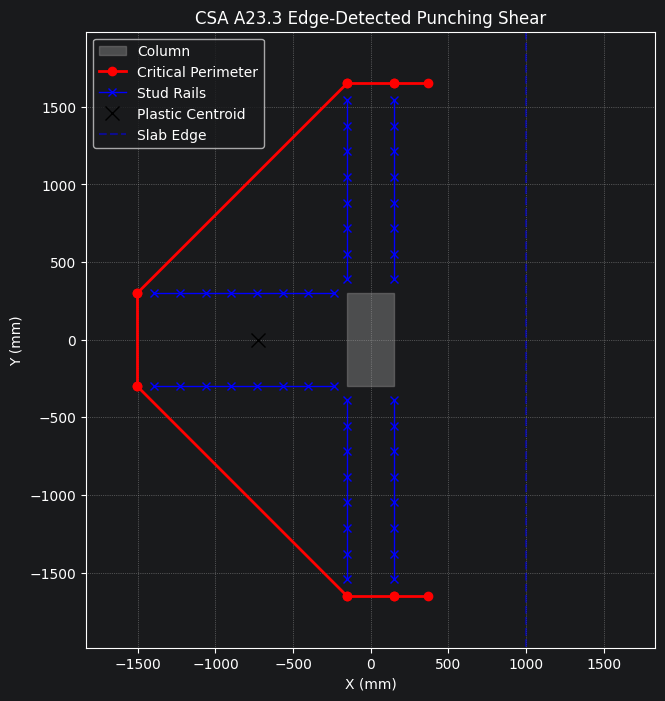

✅ OUTER PERIMETER PASSES at rail length: 1243.0 mm
Outer v_f: 0.731 MPa (Limit: 0.731 MPa)

--- SSR Detailing ---
Stud Diameter: 12.7 mm
Number of Rails: 8
Studs per Rail: 8
Distance to First Stud (s0): 88.0 mm
Spacing Between Studs (s): 165.0 mm
Total Rail Length: 1243.0 mm


In [54]:
# 4. CSA A23.3-19 Capacity Checks
v_c, d_factor = calc_vc_unreinforced(inputs, geometry)
v_r_max = check_maximum_ssr_stress(inputs)

gamma_vx = calc_gamma_v(inputs, "x")
gamma_vy = calc_gamma_v(inputs, "y")

vf = calc_max_shear_stress(
    v_f=inputs.Vf * 1000,
    m_fx=inputs.Mf_x * 1e6,
    m_fy=inputs.Mf_y * 1e6,
    inputs=inputs,
    geometry=geometry,
    gamma_vx=gamma_vx,
    gamma_vy=gamma_vy
)

print("--- Code Checks ---")
print(f"v_f (Factored Shear Stress): {vf:.3f} MPa")
print(f"v_c (Unreinforced Capacity): {v_c:.3f} MPa")
print(f"v_r_max (Max Allowed w/ SSR):  {v_r_max:.3f} MPa\n")

if vf <= v_c:
    print("✅ PASS: Unreinforced capacity is adequate.")
elif vf <= v_r_max:
    print("⚠️ WARNING: Unreinforced capacity exceeded. SSR Required!")

    # 5. SSR Design Loop
    ssr_design = design_ssr_rails(inputs, slab_bounds, geometry, vf, stud_diameter=12.7)

    print("\n--- SSR Design Results ---")
    if ssr_design["success"]:
        # We dynamically plot the reinforced perimeter & the stud rails!
        from Utilities.plotting import plot_punching_shear
        # print("\n--- Generating Outer Perimeter Plot ---")
        plot_punching_shear(
            inputs.x_c, inputs.y_c, inputs.c1, inputs.c2,
            ssr_design['outer_perimeter_line'],
            ssr_design['final_geometry'].cx_plastic,
            ssr_design['final_geometry'].cy_plastic,
            slab_bounds, inputs.d,
            stud_rails=ssr_design['stud_rails'],
            required_rail_length=ssr_design['required_rail_length']
        )
        print(f"✅ OUTER PERIMETER PASSES at rail length: {ssr_design['required_rail_length']:.1f} mm")
        print(f"Outer v_f: {ssr_design['vf_out']:.3f} MPa (Limit: {ssr_design['v_c_out_limit']:.3f} MPa)")

        print(f"\n--- SSR Detailing ---")
        print(f"Stud Diameter: {ssr_design['stud_diameter']} mm")
        print(f"Number of Rails: {ssr_design['num_rails']}")
        print(f"Studs per Rail: {ssr_design['num_studs_per_rail']}")
        print(f"Distance to First Stud (s0): {ssr_design['s0']:.1f} mm")
        print(f"Spacing Between Studs (s): {ssr_design['s']:.1f} mm")
        print(f"Total Rail Length: {ssr_design['required_rail_length']:.1f} mm")
    else:
        print(f"❌ SSR Design Failed: {ssr_design['message']}")
else:
    print("❌ FAIL: Stress exceeds v_r_max. Section must be resized.")